In [3]:
import os
import gc
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import ViTForImageClassification, ViTImageProcessor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
MODEL_NAME = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

masking_eval_model = ViTForImageClassification.from_pretrained(MODEL_NAME)
masking_eval_model.eval()
masking_eval_model = masking_eval_model.to(device)

masking_eval_model = nn.DataParallel(masking_eval_model)

patch_size = 16
img_size = 224
grid_size = img_size // patch_size

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [5]:
from torchvision.datasets import Imagenette

base_val_ds = Imagenette(root="./data", split="val", size="320px", download=True)

WNID_TO_IMAGENET1K = {
    "n01440764": 0, "n02102040": 217, "n02979186": 482, "n03000684": 491,
    "n03028079": 497, "n03394916": 566, "n03417042": 569, "n03425413": 571,
    "n03445777": 574, "n03888257": 701,
}

local_idx_to_imagenet1k = {
    local_id: WNID_TO_IMAGENET1K[wnid] 
    for wnid, local_id in base_val_ds.wnid_to_idx.items()
}

N_EVAL = 600
rng = np.random.RandomState(SEED)
max_len = min(N_EVAL, len(base_val_ds))
eval_indices = rng.choice(len(base_val_ds), size=max_len, replace=False)

print(f"Eval subset: {len(eval_indices)} images")

mean = torch.tensor(processor.image_mean).view(3, 1, 1)
std = torch.tensor(processor.image_std).view(3, 1, 1)

class MaskedImagenetteDataset(Dataset):
    def __init__(self, base_ds, indices, idx_map, mask_fraction=0.0, mask_mode="none", seed=0):
        self.base_ds = base_ds
        self.indices = indices
        self.idx_map = idx_map
        self.mask_fraction = mask_fraction
        self.mask_mode = mask_mode
        self.rng = np.random.RandomState(seed)

    def __len__(self): 
        return len(self.indices)

    def _generate_mask_grid(self):
        n_patches = grid_size * grid_size
        n_mask = int(round(self.mask_fraction * n_patches))
        mask = np.zeros(n_patches, dtype=bool)
        
        if self.mask_mode == "none" or n_mask == 0:
            return mask.reshape(grid_size, grid_size)
            
        if self.mask_mode == "random":
            chosen_patches = self.rng.choice(n_patches, size=n_mask, replace=False)
            mask[chosen_patches] = True
            
        elif self.mask_mode == "center":
            cy, cx = grid_size // 2, grid_size // 2
            
            coords = []
            for i in range(grid_size):
                for j in range(grid_size):
                    dist = (i - cy)**2 + (j - cx)**2
                    coords.append((dist, i, j))
                    
            coords.sort(key=lambda x: x[0])
            
            for _, i, j in coords[:n_mask]:
                mask[i * grid_size + j] = True
                
        return mask.reshape(grid_size, grid_size)

    def __getitem__(self, i):
        img, local_label = self.base_ds[self.indices[i]]
        
        img = img.convert("RGB").resize((img_size, img_size))
        x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        x = (x - mean) / std
        
        mask_grid = self._generate_mask_grid()
        if mask_grid.any():
            mask_tensor = torch.from_numpy(mask_grid)
            full_mask = mask_tensor.repeat_interleave(patch_size, 0).repeat_interleave(patch_size, 1)
            x = x * (~full_mask).float().unsqueeze(0)
            
        global_label = self.idx_map[local_label]
        return x, global_label

def make_loader(mask_fraction, mask_mode, batch_size=32):
    ds = MaskedImagenetteDataset(
        base_val_ds, 
        eval_indices, 
        local_idx_to_imagenet1k, 
        mask_fraction, 
        mask_mode, 
        seed=SEED
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 342M/342M [00:07<00:00, 46.4MB/s] 


Eval subset: 600 images


In [6]:
MASK_FRACTIONS = [0.0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85]

@torch.no_grad()
def evaluate(mask_fraction, mask_mode):
    loader = make_loader(mask_fraction, mask_mode)
    correct_preds = 0
    total_samples = 0
    confidence_sum = 0.0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = masking_eval_model(pixel_values=x).logits
        
        probs = F.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)
        
        correct_preds += (pred == y).sum().item()
        confidence_sum += conf.sum().item()
        total_samples += y.size(0)
        
    accuracy = correct_preds / total_samples
    avg_confidence = confidence_sum / total_samples
    
    return accuracy, avg_confidence

random_results, random_conf = [], []
center_results, center_conf = [], []

for frac in MASK_FRACTIONS:
    random_mode = "random" if frac > 0 else "none"
    center_mode = "center" if frac > 0 else "none"
    
    acc_r, conf_r = evaluate(frac, random_mode)
    acc_c, conf_c = evaluate(frac, center_mode)
    
    random_results.append(acc_r)
    random_conf.append(conf_r)
    center_results.append(acc_c)
    center_conf.append(conf_c)
    
    print(f"Mask: {frac:.0%} | Random: Acc={acc_r:.3f}, Conf={conf_r:.3f} | Center: Acc={acc_c:.3f}, Conf={conf_c:.3f}")
    
    gc.collect()
    torch.cuda.empty_cache()

Mask: 0% | Random: Acc=0.865, Conf=0.872 | Center: Acc=0.865, Conf=0.872
Mask: 10% | Random: Acc=0.838, Conf=0.859 | Center: Acc=0.787, Conf=0.821
Mask: 25% | Random: Acc=0.802, Conf=0.840 | Center: Acc=0.632, Conf=0.705
Mask: 40% | Random: Acc=0.758, Conf=0.796 | Center: Acc=0.430, Conf=0.570
Mask: 55% | Random: Acc=0.645, Conf=0.716 | Center: Acc=0.320, Conf=0.456
Mask: 70% | Random: Acc=0.473, Conf=0.574 | Center: Acc=0.205, Conf=0.354
Mask: 85% | Random: Acc=0.232, Conf=0.357 | Center: Acc=0.112, Conf=0.225


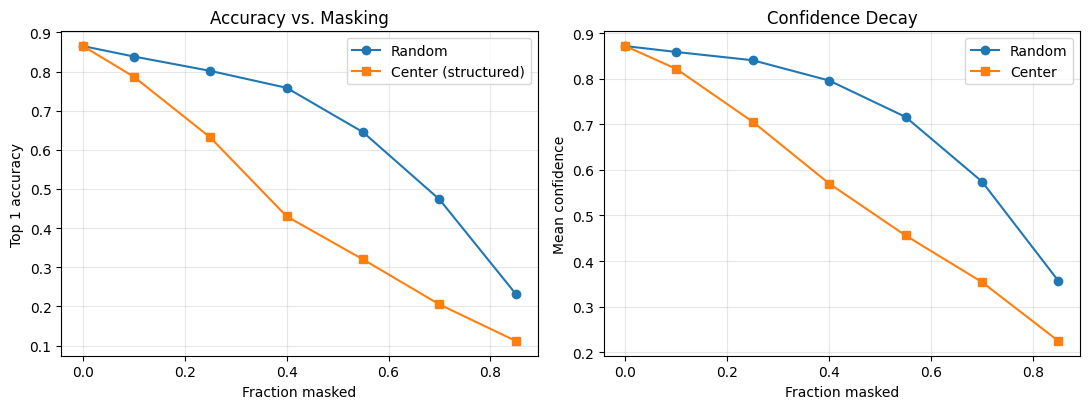

In [7]:
def plot_masking_curves(fractions, rand_acc, cent_acc, rand_conf, cent_conf, save_path="./masking_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    
    #accuracy
    axes[0].plot(fractions, rand_acc, "o-", label="Random")
    axes[0].plot(fractions, cent_acc, "s-", label="Center (structured)")
    axes[0].set_xlabel("Fraction masked")
    axes[0].set_ylabel("Top 1 accuracy")
    axes[0].set_title("Accuracy vs. Masking")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    #confidence 
    axes[1].plot(fractions, rand_conf, "o-", label="Random")
    axes[1].plot(fractions, cent_conf, "s-", label="Center")
    axes[1].set_xlabel("Fraction masked")
    axes[1].set_ylabel("Mean confidence")
    axes[1].set_title("Confidence Decay")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_masking_curves(MASK_FRACTIONS, random_results, center_results, random_conf, center_conf)

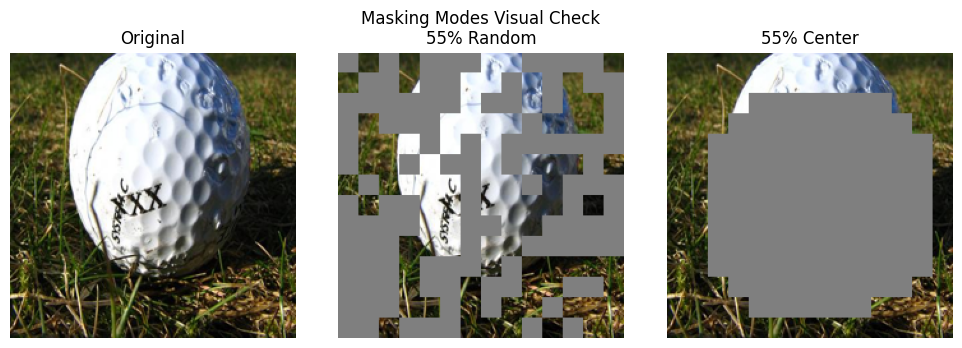

In [8]:
def plot_mask_examples(save_path="./mask_examples.png"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    modes = ["none", "random", "center"]
    titles = ["Original", "55% Random", "55% Center"]
    
    for ax, mode, title in zip(axes, modes, titles):
        fraction = 0.55 if mode != "none" else 0.0
        
        ds = MaskedImagenetteDataset(
            base_val_ds, 
            [eval_indices[0]], 
            local_idx_to_imagenet1k,
            mask_fraction=fraction, 
            mask_mode=mode, 
            seed=SEED
        )
        
        x, _ = ds[0]
        
        #denormalize and format for matplotlib
        img_tensor = (x * std + mean).clamp(0, 1).permute(1, 2, 0)
        
        ax.imshow(img_tensor.numpy())
        ax.axis("off")
        ax.set_title(title)
        
    plt.suptitle("Masking Modes Visual Check")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_mask_examples()

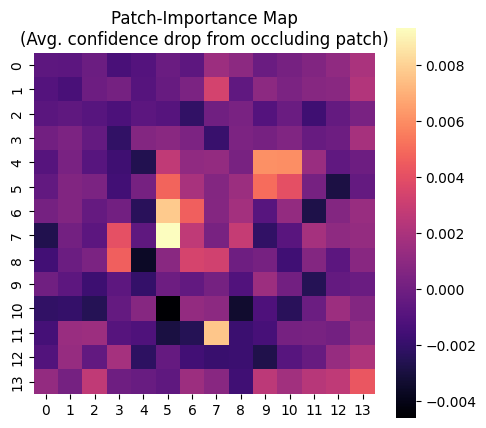

In [9]:
OCCLUSION_SUBSET = eval_indices[:80]

@torch.no_grad()
def calculate_occlusion_sensitivity(indices, batch_size=98):
    drop_map = np.zeros((grid_size, grid_size))
    n_patches = grid_size * grid_size
    
    for idx in indices:
        img, local_label = base_val_ds[idx]
        img = img.convert("RGB").resize((img_size, img_size))
        x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        x = ((x - mean) / std).to(device)

        #baseline confidence score
        base_logits = masking_eval_model(pixel_values=x.unsqueeze(0)).logits
        base_probs = F.softmax(base_logits, dim=-1)
        base_class = base_probs.argmax(dim=-1).item()
        base_conf = base_probs[0, base_class].item()

        confs = np.zeros(n_patches)
        
        for start in range(0, n_patches, batch_size):
            end = min(start + batch_size, n_patches)
            current_batch_size = end - start
            
            batch = x.unsqueeze(0).repeat(current_batch_size,1,1,1).clone()
            for k, p in enumerate(range(start, end)):
                i, j = divmod(p, grid_size)
                y_start, y_end = i * patch_size,(i + 1) * patch_size
                x_start, x_end = j* patch_size,(j + 1) * patch_size
                batch[k, :, y_start:y_end, x_start:x_end] = 0.0
                
            batch_logits = masking_eval_model(pixel_values=batch).logits
            probs = F.softmax(batch_logits, dim=-1)
            confs[start:end] = probs[:, base_class].detach().cpu().numpy()
            
        #confidence drops
        drop_map += (base_conf - confs).reshape(grid_size, grid_size)
        
    return drop_map / len(indices)

def plot_occlusion_heatmap(drop_map, save_path="./occlusion_map.png"):
    plt.figure(figsize=(5, 4.5))
    sns.heatmap(drop_map, cmap="magma", square=True)
    plt.title("Patch-Importance Map\n(Avg. confidence drop from occluding patch)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

avg_drop_map = calculate_occlusion_sensitivity(OCCLUSION_SUBSET)
plot_occlusion_heatmap(avg_drop_map)